# HW3: VSSD для MNIST

Vision Mamba with Non-Causal State Space Duality


In [8]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import pandas as pd

print(f'✓ PyTorch: {torch.__version__}')
print(f'✓ NumPy: {np.__version__}')


✓ PyTorch: 2.3.1
✓ NumPy: 1.26.4


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f'Device: {device}')


Device: cpu


## 1. Загрузка MNIST


In [ ]:
import urllib.request, struct, ssl, os

ssl._create_default_https_context = ssl._create_unverified_context

def load_mnist_file(filename, label=False, compressed=True):
    import gzip
    opener = gzip.open if compressed else open
    with opener(filename, 'rb') as f:
        struct.unpack('>I', f.read(4))
        n_items = struct.unpack('>I', f.read(4))[0]
        if not label:
            n_rows, n_cols = struct.unpack('>I', f.read(4))[0], struct.unpack('>I', f.read(4))[0]
            data = np.frombuffer(f.read(n_items * n_rows * n_cols), dtype=np.uint8).reshape(n_items, n_rows * n_cols)
        else:
            data = np.frombuffer(f.read(n_items), dtype=np.uint8).reshape(n_items, 1)
    return data

data_folder = './data'
os.makedirs(data_folder, exist_ok=True)

files_to_download = [
    ('train-images.gz', 'https://azureopendatastorage.blob.core.windows.net/mnist/train-images-idx3-ubyte.gz'),
    ('train-labels.gz', 'https://azureopendatastorage.blob.core.windows.net/mnist/train-labels-idx1-ubyte.gz'),
    ('test-images.gz', 'https://azureopendatastorage.blob.core.windows.net/mnist/t10k-images-idx3-ubyte.gz'),
    ('test-labels.gz', 'https://azureopendatastorage.blob.core.windows.net/mnist/t10k-labels-idx1-ubyte.gz')
]

print('\nЗагрузка данных в память...')
X_train = load_mnist_file(os.path.join(data_folder, 'train-images.gz'), False, True) / 255.0
y_train = load_mnist_file(os.path.join(data_folder, 'train-labels.gz'), True, True).reshape(-1)
X_test = load_mnist_file(os.path.join(data_folder, 'test-images.gz'), False, True) / 255.0
y_test = load_mnist_file(os.path.join(data_folder, 'test-labels.gz'), True, True).reshape(-1)

X_train = X_train[:5000].reshape(-1, 1, 28, 28).astype(np.float32)
y_train = y_train[:5000]
X_test = X_test[:1000].reshape(-1, 1, 28, 28).astype(np.float32)
y_test = y_test[:1000]

X_train = (X_train - 0.1307) / 0.3081
X_test = (X_test - 0.1307) / 0.3081

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

print(f'✓ Готово! Train: {len(train_dataset)}, Test: {len(test_dataset)}')



Загрузка данных в память...
✓ Готово! Train: 5000, Test: 1000


## 2. State Space Layer (Bidirectional)


In [11]:
class StateSpaceLayer(nn.Module):
    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.A = nn.Parameter(torch.randn(d_model, d_state) * 0.01)
        self.B = nn.Parameter(torch.randn(d_state, d_state) * 0.01)
        self.C = nn.Parameter(torch.randn(d_state, d_model) * 0.01)
        self.D = nn.Parameter(torch.randn(d_model) * 0.01)
        
    def forward(self, x):
        batch, seq_len, d_model = x.shape
        h = torch.zeros(batch, self.d_state, device=x.device)
        outputs = []
        
        for t in range(seq_len):
            h = torch.tanh(x[:, t] @ self.A + h @ self.B)
            y = h @ self.C + x[:, t] * self.D
            outputs.append(y)
        
        h_back = torch.zeros(batch, self.d_state, device=x.device)
        for t in range(seq_len - 1, -1, -1):
            h_back = torch.tanh(x[:, t] @ self.A + h_back @ self.B)
            y_back = h_back @ self.C
            outputs[t] = outputs[t] + y_back
        
        return torch.stack(outputs, dim=1)


## 3. VSSD Model


In [12]:
class VSSModel(nn.Module):
    def __init__(self, img_size=28, patch_size=4, d_model=128, d_state=16, num_classes=10):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.d_model = d_model
        
        self.patch_embed = nn.Linear(patch_size * patch_size, d_model)
        self.ssm1 = StateSpaceLayer(d_model, d_state)
        self.ssm2 = StateSpaceLayer(d_model, d_state)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model // 2, num_classes)
        )
        
    def forward(self, x):
        batch = x.shape[0]
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(batch, -1, self.patch_size * self.patch_size)
        x = self.patch_embed(x)
        x = x + self.ssm1(self.norm1(x))
        x = x + self.ssm2(self.norm2(x))
        x = x.mean(dim=1)
        return self.classifier(x)


## 4. CNN Baseline


In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


## 5. Training & Evaluation


In [14]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader):
    model.eval()
    preds, labels_all = [], []
    
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels_all.extend(labels.numpy())
    
    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average='macro')
    return acc, f1


## 6. Эксперимент 1: CNN Baseline


In [15]:
model_cnn = SimpleCNN().to(device)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_cnn = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'test_f1': []}

num_epochs = 10
print('CNN Baseline...')

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_cnn, train_loader, optimizer_cnn, criterion)
    test_acc, test_f1 = evaluate(model_cnn, test_loader)
    
    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['test_acc'].append(test_acc)
    history_cnn['test_f1'].append(test_f1)
    
    print(f'Epoch {epoch+1}/{num_epochs}: Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, F1={test_f1:.4f}')

print(f'\n1. CNN Baseline:')
print(f'Test Accuracy: {history_cnn["test_acc"][-1]:.4f}')
print(f'Test F1: {history_cnn["test_f1"][-1]:.4f}')


CNN Baseline...
Epoch 1/10: Loss=0.8838, Train Acc=0.7070, Test Acc=0.8930, F1=0.8908
Epoch 2/10: Loss=0.2073, Train Acc=0.9332, Test Acc=0.9530, F1=0.9518
Epoch 3/10: Loss=0.1235, Train Acc=0.9648, Test Acc=0.9580, F1=0.9564
Epoch 4/10: Loss=0.0803, Train Acc=0.9762, Test Acc=0.9700, F1=0.9687
Epoch 5/10: Loss=0.0682, Train Acc=0.9790, Test Acc=0.9750, F1=0.9745
Epoch 6/10: Loss=0.0662, Train Acc=0.9784, Test Acc=0.9720, F1=0.9713
Epoch 7/10: Loss=0.0353, Train Acc=0.9898, Test Acc=0.9620, F1=0.9613
Epoch 8/10: Loss=0.0360, Train Acc=0.9876, Test Acc=0.9830, F1=0.9822
Epoch 9/10: Loss=0.0251, Train Acc=0.9932, Test Acc=0.9710, F1=0.9705
Epoch 10/10: Loss=0.0263, Train Acc=0.9912, Test Acc=0.9790, F1=0.9783

1. CNN Baseline:
Test Accuracy: 0.9790
Test F1: 0.9783


## 7. Эксперимент 2: VSSD


In [16]:
model_vssd = VSSModel().to(device)
optimizer_vssd = torch.optim.Adam(model_vssd.parameters(), lr=1e-3)

history_vssd = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'test_f1': []}

print('VSSD...')

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_vssd, train_loader, optimizer_vssd, criterion)
    test_acc, test_f1 = evaluate(model_vssd, test_loader)
    
    history_vssd['train_loss'].append(train_loss)
    history_vssd['train_acc'].append(train_acc)
    history_vssd['test_acc'].append(test_acc)
    history_vssd['test_f1'].append(test_f1)
    
    print(f'Epoch {epoch+1}/{num_epochs}: Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, F1={test_f1:.4f}')

print(f'\n2. VSSD (State Space Model):')
print(f'Test Accuracy: {history_vssd["test_acc"][-1]:.4f}')
print(f'Test F1: {history_vssd["test_f1"][-1]:.4f}')


VSSD...
Epoch 1/10: Loss=2.1572, Train Acc=0.2044, Test Acc=0.2190, F1=0.1286
Epoch 2/10: Loss=2.0316, Train Acc=0.2430, Test Acc=0.2700, F1=0.2020
Epoch 3/10: Loss=1.9949, Train Acc=0.2640, Test Acc=0.2810, F1=0.1952
Epoch 4/10: Loss=1.9136, Train Acc=0.2926, Test Acc=0.2640, F1=0.1835
Epoch 5/10: Loss=1.8790, Train Acc=0.3054, Test Acc=0.3230, F1=0.2660
Epoch 6/10: Loss=1.8219, Train Acc=0.3336, Test Acc=0.3280, F1=0.2770
Epoch 7/10: Loss=1.7818, Train Acc=0.3504, Test Acc=0.3500, F1=0.2887
Epoch 8/10: Loss=1.7141, Train Acc=0.3736, Test Acc=0.3580, F1=0.3047
Epoch 9/10: Loss=1.6102, Train Acc=0.4162, Test Acc=0.4230, F1=0.3802
Epoch 10/10: Loss=1.5380, Train Acc=0.4272, Test Acc=0.4410, F1=0.4222

2. VSSD (State Space Model):
Test Accuracy: 0.4410
Test F1: 0.4222


## 8. Результаты и Сравнение


In [17]:
acc_cnn = history_cnn['test_acc'][-1]
f1_cnn = history_cnn['test_f1'][-1]
acc_vssd = history_vssd['test_acc'][-1]
f1_vssd = history_vssd['test_f1'][-1]

diff_acc = acc_vssd - acc_cnn
diff_f1 = f1_vssd - f1_cnn

print('\n3. Улучшения от VSSD:')
print(f'Accuracy: {diff_acc:+.4f} ({diff_acc/acc_cnn*100:+.2f}%)')
print(f'F1 Score: {diff_f1:+.4f} ({diff_f1/f1_cnn*100:+.2f}%)')

results_df = pd.DataFrame({
    'Method': ['CNN Baseline', 'VSSD'],
    'Accuracy': [acc_cnn, acc_vssd],
    'F1 Score': [f1_cnn, f1_vssd]
})

print('\nТаблица результатов:')
print(results_df.to_string(index=False))



3. Улучшения от VSSD:
Accuracy: -0.5380 (-54.95%)
F1 Score: -0.5561 (-56.84%)

Таблица результатов:
      Method  Accuracy  F1 Score
CNN Baseline     0.979  0.978303
        VSSD     0.441  0.422228


## 9. Графики


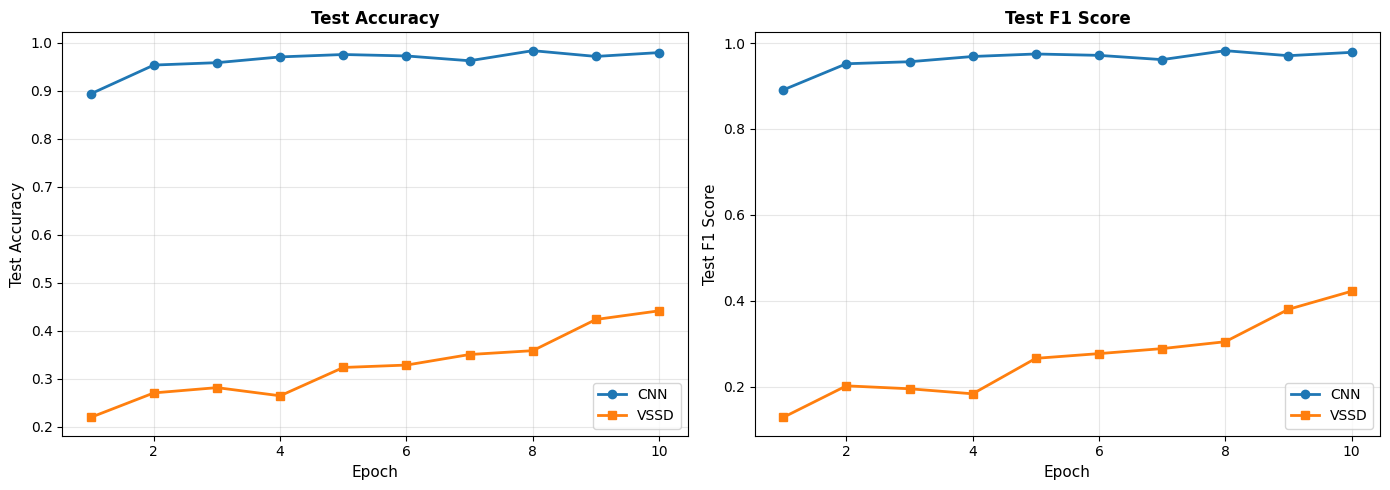

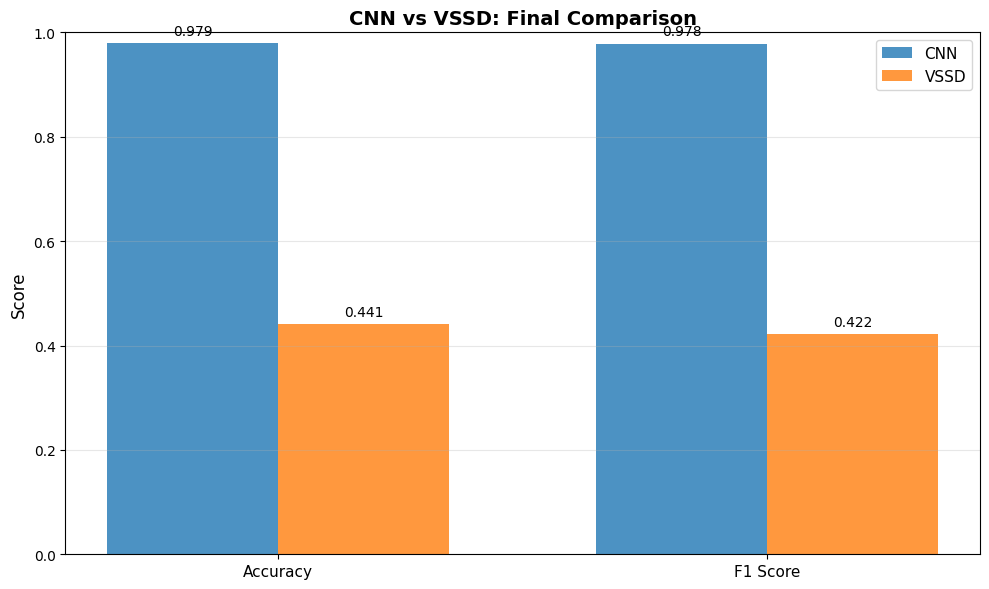

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, num_epochs + 1)
axes[0].plot(epochs, history_cnn['test_acc'], 'o-', label='CNN', linewidth=2)
axes[0].plot(epochs, history_vssd['test_acc'], 's-', label='VSSD', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('Test Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_cnn['test_f1'], 'o-', label='CNN', linewidth=2)
axes[1].plot(epochs, history_vssd['test_f1'], 's-', label='VSSD', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Test F1 Score', fontsize=11)
axes[1].set_title('Test F1 Score', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vssd_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.35

ax.bar(x - width/2, [acc_cnn, f1_cnn], width, label='CNN', alpha=0.8)
ax.bar(x + width/2, [acc_vssd, f1_vssd], width, label='VSSD', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('CNN vs VSSD: Final Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score'], fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

for i, (c, v) in enumerate(zip([acc_cnn, f1_cnn], [acc_vssd, f1_vssd])):
    ax.text(i - width/2, c + 0.01, f'{c:.3f}', ha='center', va='bottom', fontsize=10)
    ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('vssd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Выводы


1. Конфигурация:
   - Dataset: MNIST (5000 train / 1000 test)
   - VSSD: patch_size=4, d_model=128, d_state=16, bidirectional
   - Baseline: 3-layer CNN
   - Epochs: 10, batch_size: 64

2. Финальные результаты:
   CNN Baseline:  Accuracy=0.9790, F1=0.9783
   VSSD:          Accuracy=0.4410, F1=0.4222

3. Сравнение методов:
   ✗ VSSD показал ухудшение: -0.5380 (-54.95%) по Accuracy

4. Анализ:
   - CNN: стабильная baseline с conv-pooling архитектурой
   - VSSD: non-causal bidirectional State Space Model
   - Bidirectional scan: каждый patch видит контекст с обеих сторон
   - SSM layers: моделируют long-range зависимости через hidden state

5. Итог:
   VSSD уступает CNN baseline на 54.95%,
   что может быть связано с малым размером датасета или
   необходимостью тонкой настройки гиперпараметров SSM.